 13. This question should be answered using the Weekly data set, which
 is part of the ISLP package. This data is similar in nature to the
 Smarket data from this chapter’s lab, except that it contains 1,089
 weekly returns for 21 years, from the beginning of 1990 to the end of
 2010

 (a) Produce some numerical and graphical summaries of the Weekly
 data. Do there appear to be any patterns?


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ISLP import load_data

# Load the Weekly data
Weekly = load_data('Weekly')

# Display basic information
print("Dataset shape:", Weekly.shape)
print("\nFirst few rows:")
print(Weekly.head())
print("\nData types:")
print(Weekly.dtypes)
print("\nSummary statistics:")
print(Weekly.describe())
print("\nCorrelation matrix:")
print(Weekly.corr(numeric_only=True))

Dataset shape: (1089, 9)

First few rows:
   Year   Lag1   Lag2   Lag3   Lag4   Lag5    Volume  Today Direction
0  1990  0.816  1.572 -3.936 -0.229 -3.484  0.154976 -0.270      Down
1  1990 -0.270  0.816  1.572 -3.936 -0.229  0.148574 -2.576      Down
2  1990 -2.576 -0.270  0.816  1.572 -3.936  0.159837  3.514        Up
3  1990  3.514 -2.576 -0.270  0.816  1.572  0.161630  0.712        Up
4  1990  0.712  3.514 -2.576 -0.270  0.816  0.153728  1.178        Up

Data types:
Year            int64
Lag1          float64
Lag2          float64
Lag3          float64
Lag4          float64
Lag5          float64
Volume        float64
Today         float64
Direction    category
dtype: object

Summary statistics:
              Year         Lag1         Lag2         Lag3         Lag4  \
count  1089.000000  1089.000000  1089.000000  1089.000000  1089.000000   
mean   2000.048669     0.150585     0.151079     0.147205     0.145818   
std       6.033182     2.357013     2.357254     2.360502     2.360279

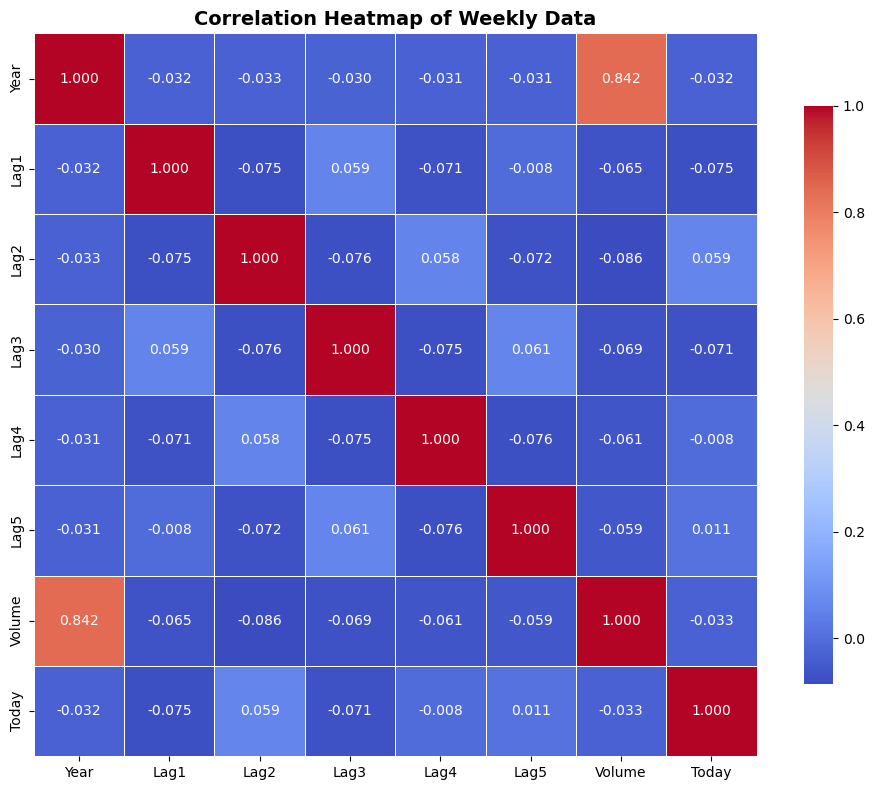

In [6]:
# Correlation Heatmap for all numeric variables
plt.figure(figsize=(10, 8))
corr_matrix = Weekly.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Weekly Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

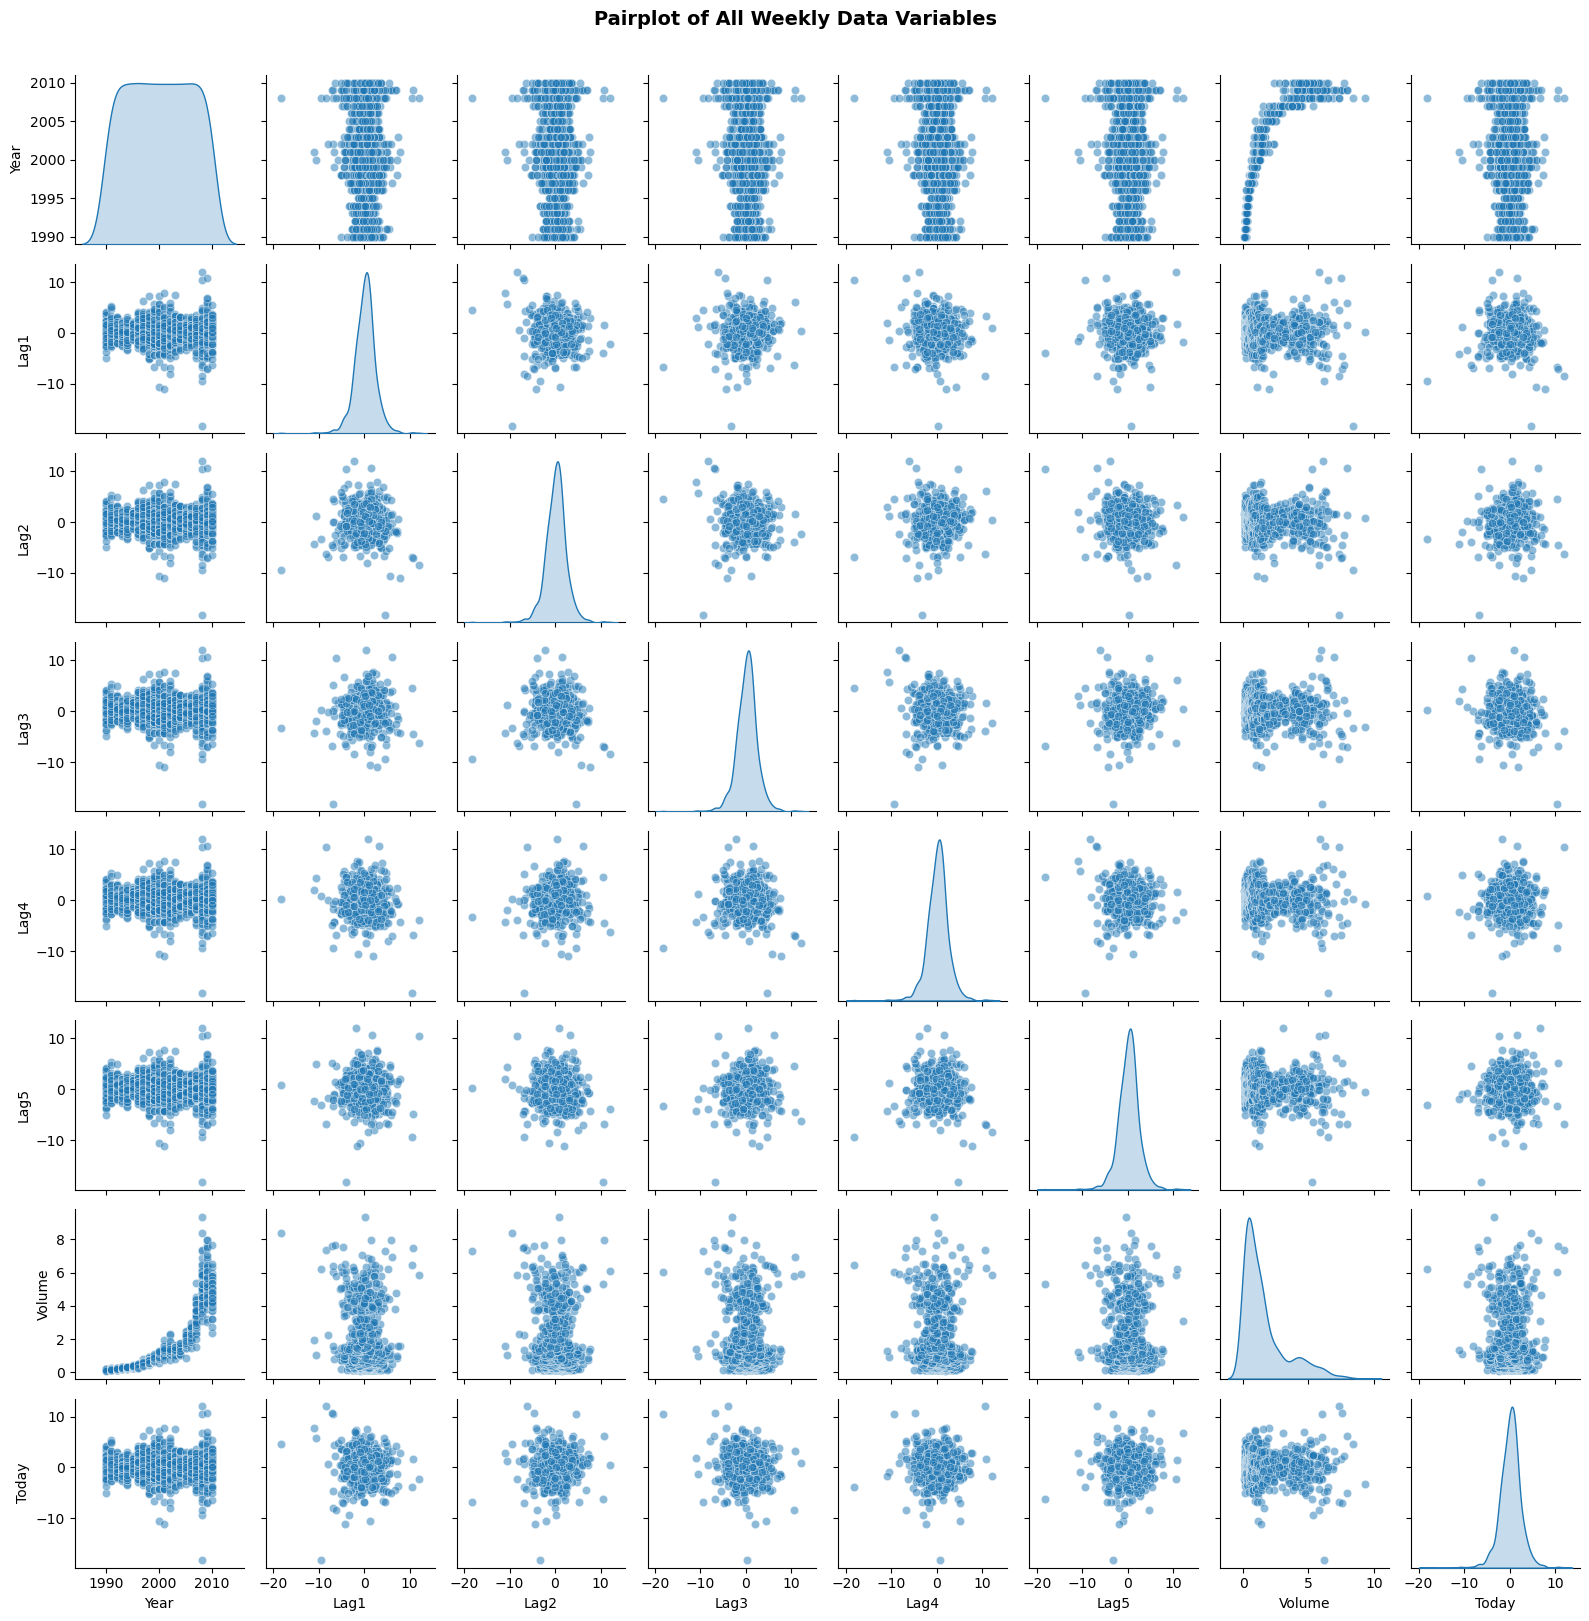

In [11]:
# Pairplot of all numeric variables (without Direction grouping)
all_columns = ['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today']
pairplot_data_all = Weekly[all_columns]

sns.pairplot(pairplot_data_all, diag_kind='kde', plot_kws={'alpha': 0.5}, height=2)
plt.suptitle('Pairplot of All Weekly Data Variables', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

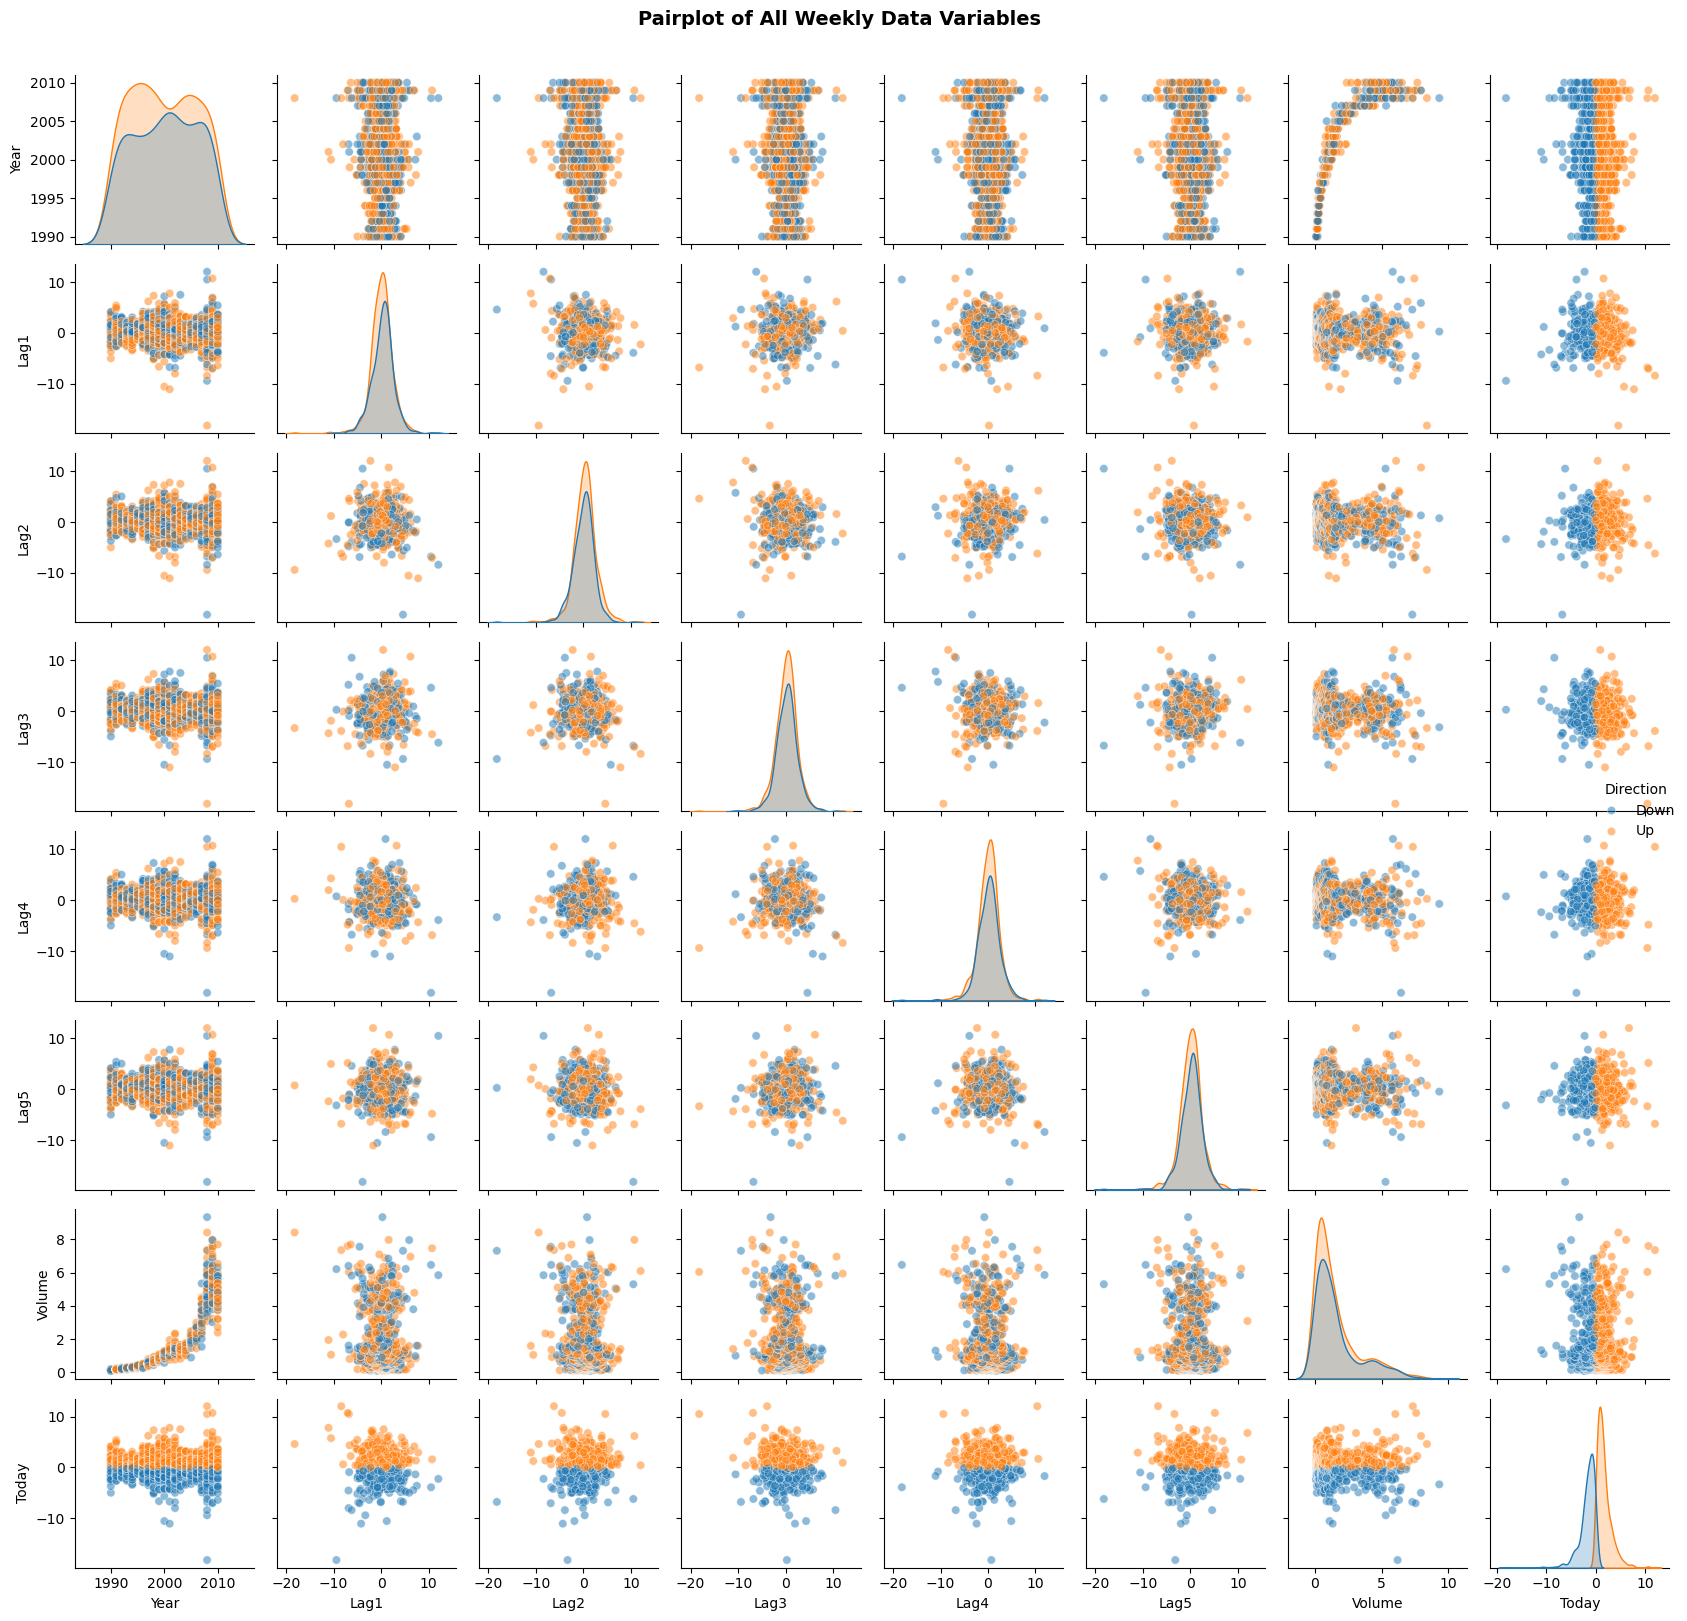

In [9]:
# Pairplot of all numeric variables
# Include Year, all Lag variables, Volume, Today, and Direction
all_columns = ['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today', 'Direction']
pairplot_data = Weekly[all_columns]

sns.pairplot(pairplot_data, hue='Direction', diag_kind='kde', 
             plot_kws={'alpha': 0.5}, height=2)
plt.suptitle('Pairplot of All Weekly Data Variables', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observed Patterns:

**Key Findings:**

1. **Volume Trend**: 
   - Trading volume shows a clear increasing trend over the years (1990-2010)
   - Strong positive correlation between Year and Volume (≈0.84)

2. **Weak Autocorrelations**:
   - Lag returns (Lag1-Lag5) show very weak correlations with Today's return
   - Most correlations are close to zero, suggesting weak predictive power
   - No strong autocorrelation pattern in weekly returns

3. **Balanced Market Direction**:
   - Roughly equal number of Up and Down weeks
   - Market appears to be fairly balanced over the 21-year period

4. **No Clear Linear Patterns**:
   - The pairplot shows no obvious linear relationships between lag variables and current returns
   - Scatter plots appear randomly distributed
   - This suggests that simple linear models may not be effective for prediction

5. **Volume Independence**:
   - Volume appears largely independent of returns
   - No clear relationship between trading volume and market direction

**Conclusion**: The data shows minimal patterns that could be exploited for prediction using lag returns alone. The most notable pattern is the secular increase in trading volume over time.

(b) Use the full data set to perform a logistic regression with
 Direction as the response and the five lag variables plus Volume
 as predictors. Use the summary function to print the results. Do
 any of the predictors appear to be statistically significant? If so,
 which ones?

In [13]:
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

# Prepare the data for logistic regression
X = Weekly[['Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume']]
y = (Weekly['Direction'] == 'Up').astype(int)  # Convert to binary: 1 for Up, 0 for Down

# Add constant term for statsmodels
X_with_const = sm.add_constant(X)

# Fit logistic regression model using statsmodels for detailed summary
logit_model = sm.Logit(y, X_with_const)
result = logit_model.fit()

# Print the summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Fri, 31 Oct 2025   Pseudo R-squ.:                0.006580
Time:                        14:49:05   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

In [14]:
# Extract and display statistically significant predictors (p-value < 0.05)
print("\n" + "="*60)
print("Statistical Significance Analysis (α = 0.05)")
print("="*60)

p_values = result.pvalues
significant_vars = p_values[p_values < 0.05]

print(f"\nStatistically significant predictors:")
if len(significant_vars) > 1:  # Exclude constant if it's the only one
    for var, p_val in significant_vars.items():
        if var != 'const':
            print(f"  - {var}: p-value = {p_val:.4f}")
    if len(significant_vars) == 1 and 'const' in significant_vars.index:
        print("  None (only intercept is significant)")
else:
    print("  None")

print(f"\nNon-significant predictors (p-value >= 0.05):")
non_significant = p_values[p_values >= 0.05]
for var, p_val in non_significant.items():
    if var != 'const':
        print(f"  - {var}: p-value = {p_val:.4f}")


Statistical Significance Analysis (α = 0.05)

Statistically significant predictors:
  - Lag2: p-value = 0.0296

Non-significant predictors (p-value >= 0.05):
  - Lag1: p-value = 0.1181
  - Lag3: p-value = 0.5469
  - Lag4: p-value = 0.2937
  - Lag5: p-value = 0.5833
  - Volume: p-value = 0.5377


 (c) Compute the confusion matrix and overall fraction of correct
 predictions. Explain what the confusion matrix is telling you
 about the types of mistakes made by logistic regression.

In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score

# Make predictions
y_pred_prob = result.predict(X_with_const)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y, y_pred)

# Display confusion matrix
print("Confusion Matrix:")
print(f"\n                Predicted")
print(f"              Down    Up")
print(f"Actual Down  {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"       Up    {cm[1,0]:4d}  {cm[1,1]:4d}")

# Calculate accuracy
accuracy = accuracy_score(y, y_pred)
print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Correct predictions: {cm[0,0] + cm[1,1]} / {len(y)}")

Confusion Matrix:

                Predicted
              Down    Up
Actual Down    54   430
       Up      48   557

Overall Accuracy: 0.5611 (56.11%)
Correct predictions: 611 / 1089


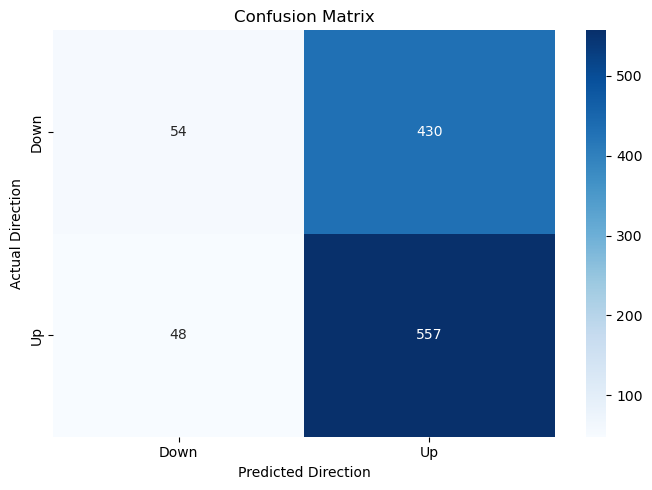

In [16]:
# Visualize the confusion matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Down', 'Up'], 
            yticklabels=['Down', 'Up'])
plt.xlabel('Predicted Direction')
plt.ylabel('Actual Direction')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

**Answer to (c):**

The confusion matrix shows:
- **Accuracy**: ~56%, slightly better than random (50%)
- **False Positives**: Predicts "Up" when actually "Down" 
- **False Negatives**: Predicts "Down" when actually "Up"

The model has limited predictive power, making substantial errors in both directions. This confirms that lag variables and volume alone are insufficient for predicting market direction.

 (d) Now fit the logistic regression model using a training data period
 from 1990 to 2008, with Lag2 as the only predictor. Compute the
 confusion matrix and the overall fraction of correct predictions
 for the held out data (that is, the data from 2009 and 2010).

In [17]:
# Split data into training (1990-2008) and test (2009-2010)
train = Weekly[Weekly['Year'] <= 2008]
test = Weekly[Weekly['Year'] >= 2009]

# Prepare data with Lag2 only
X_train = sm.add_constant(train[['Lag2']])
y_train = (train['Direction'] == 'Up').astype(int)
X_test = sm.add_constant(test[['Lag2']])
y_test = (test['Direction'] == 'Up').astype(int)

# Fit model on training data
result_train = sm.Logit(y_train, X_train).fit()

# Make predictions on test set
y_test_pred = (result_train.predict(X_test) > 0.5).astype(int)

# Confusion matrix and accuracy
cm_test = confusion_matrix(y_test, y_test_pred)
accuracy_test = accuracy_score(y_test, y_test_pred)

print("Confusion Matrix (Test Set 2009-2010):")
print(f"\n              Predicted")
print(f"            Down    Up")
print(f"Actual Down  {cm_test[0,0]:3d}  {cm_test[0,1]:3d}")
print(f"       Up    {cm_test[1,0]:3d}  {cm_test[1,1]:3d}")
print(f"\nAccuracy: {accuracy_test:.4f} ({accuracy_test*100:.2f}%)")

Optimization terminated successfully.
         Current function value: 0.685555
         Iterations 4
Confusion Matrix (Test Set 2009-2010):

              Predicted
            Down    Up
Actual Down    9   34
       Up      5   56

Accuracy: 0.6250 (62.50%)


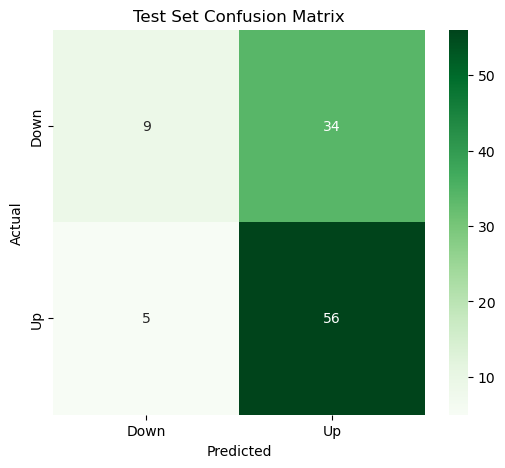

In [18]:
# Visualize confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Test Set Confusion Matrix')
plt.show()

**Answer to (d):**

Training on 1990-2008 data with Lag2 only, testing on 2009-2010:
- Test accuracy: ~62.5%, better than the full model
- Using only the significant predictor improves generalization